In [1]:
from IPython.display import HTML

import urllib.request

# add RTB examples folder to the path
import sys, os.path
import roboticstoolbox as rtb
import RVC3
# sys.path.append(os.path.join(rtb.__path__[0], 'examples'))
sys.path.append(os.path.join(RVC3.__path__[0], 'examples'))

# standard imports
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *
from roboticstoolbox import quintic, trapezoidal, mtraj, mstraj, xplot, ctraj

%matplotlib widget

### Smooth One-Dimensional Trajectories

In [2]:
traj = quintic(0, 1, np.linspace(0, 1, 50))

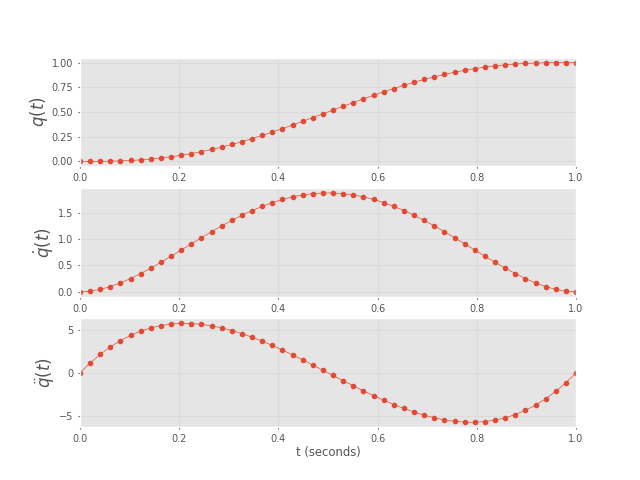

In [3]:
traj.plot()

In [4]:
traj.q

array([       0, 8.242e-05, 0.000639, 0.002089, 0.004796, 0.009065,  0.01515,  0.02326,  0.03356,  0.04615,   0.0611,
        0.07846,  0.09821,   0.1203,   0.1447,   0.1713,   0.1999,   0.2304,   0.2627,   0.2965,   0.3316,   0.3679,
          0.405,   0.4427,   0.4809,   0.5191,   0.5573,    0.595,   0.6321,   0.6684,   0.7035,   0.7373,   0.7696,
         0.8001,   0.8287,   0.8553,   0.8797,   0.9018,   0.9215,   0.9389,   0.9539,   0.9664,   0.9767,   0.9848,
         0.9909,   0.9952,   0.9979,   0.9994,   0.9999,        1])

In [5]:
traj.qd

array([       0,  0.01199,  0.04598,   0.0991,   0.1686,   0.2519,   0.3464,   0.4498,   0.5599,   0.6744,   0.7915,
         0.9093,    1.026,     1.14,    1.249,    1.354,    1.451,     1.54,     1.62,    1.691,    1.751,    1.799,
          1.836,    1.861,    1.873,    1.873,    1.861,    1.836,    1.799,    1.751,    1.691,     1.62,     1.54,
          1.451,    1.354,    1.249,     1.14,    1.026,   0.9093,   0.7915,   0.6744,   0.5599,   0.4498,   0.3464,
         0.2519,   0.1686,   0.0991,  0.04598,  0.01199,        0])

In [6]:
traj.qdd

array([       0,    1.151,    2.157,    3.026,    3.764,    4.376,    4.868,    5.248,     5.52,    5.692,    5.768,
          5.756,    5.661,     5.49,    5.248,    4.942,    4.578,    4.162,    3.699,    3.198,    2.662,    2.099,
          1.515,   0.9149,    0.306,   -0.306,  -0.9149,   -1.515,   -2.099,   -2.662,   -3.198,   -3.699,   -4.162,
         -4.578,   -4.942,   -5.248,    -5.49,   -5.661,   -5.756,   -5.768,   -5.692,    -5.52,   -5.248,   -4.868,
         -4.376,   -3.764,   -3.026,   -2.157,   -1.151,        0])

In [7]:
traj1 = quintic(0, 1, np.linspace(0, 1, 50), qd0=10, qdf=0)

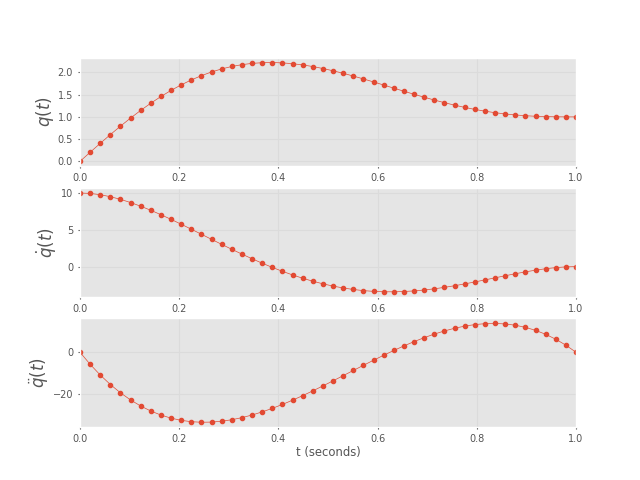

In [8]:
traj1.plot()

In [9]:
qd = traj.qd
qd.mean() / qd.max()

np.float64(0.5231022222222196)

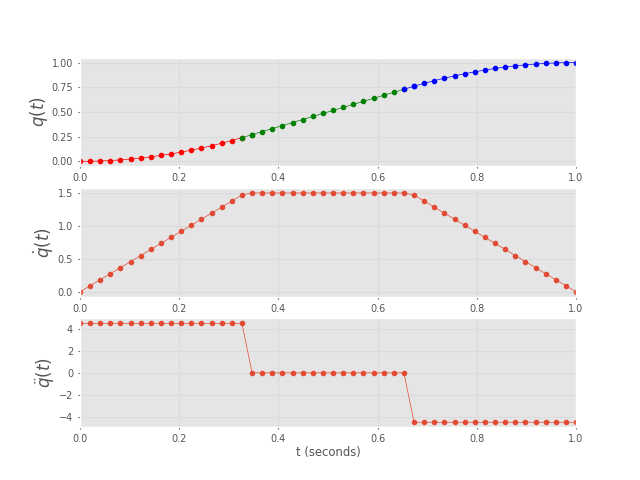

In [10]:
traj = trapezoidal(0, 1, np.linspace(0, 1, 50))
traj.plot()

In [11]:
traj.qd.max()

np.float64(1.5)

In [12]:
traj1_2 = trapezoidal(0, 1, np.linspace(0, 1, 50), V=1.2)
traj2_0 = trapezoidal(0, 1, np.linspace(0, 1, 50), V=2)

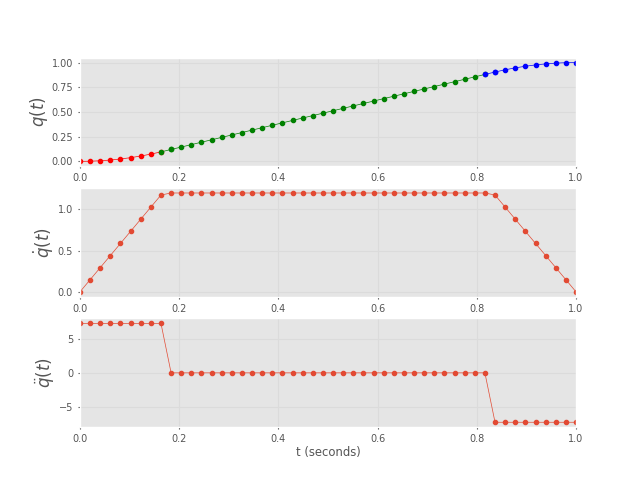

In [13]:
traj1_2.plot()

### Multi-Axis Trajectories

In [14]:
traj = mtraj(trapezoidal, [0, 2], [1, -1], 50)

In [15]:
traj.q

array([[       0,        2],
       [0.0009371,    1.997],
       [0.003748,    1.989],
       [0.008434,    1.975],
       [ 0.01499,    1.955],
       [ 0.02343,     1.93],
       [ 0.03374,    1.899],
       [ 0.04592,    1.862],
       [ 0.05998,     1.82],
       [ 0.07591,    1.772],
       [ 0.09371,    1.719],
       [  0.1134,     1.66],
       [  0.1349,    1.595],
       [  0.1584,    1.525],
       [  0.1837,    1.449],
       [  0.2108,    1.367],
       [  0.2399,     1.28],
       [  0.2704,    1.189],
       [   0.301,    1.097],
       [  0.3316,    1.005],
       [  0.3622,   0.9133],
       [  0.3929,   0.8214],
       [  0.4235,   0.7296],
       [  0.4541,   0.6378],
       [  0.4847,   0.5459],
       [  0.5153,   0.4541],
       [  0.5459,   0.3622],
       [  0.5765,   0.2704],
       [  0.6071,   0.1786],
       [  0.6378,  0.08673],
       [  0.6684, -0.005102],
       [   0.699, -0.09694],
       [  0.7296,  -0.1888],
       [  0.7601,  -0.2803],
       [  0.

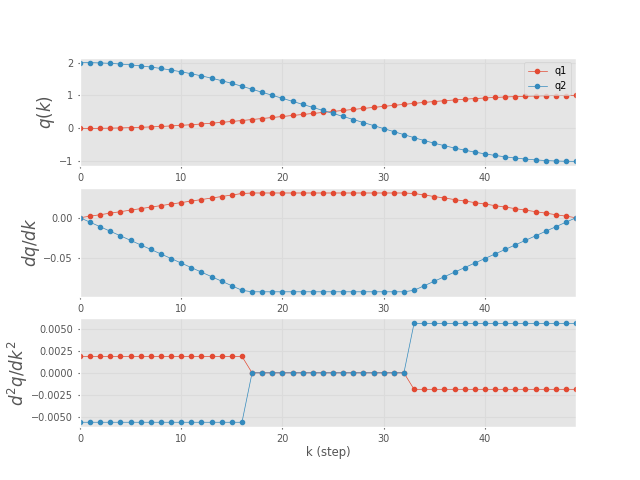

In [16]:
traj.plot()

In [17]:
T = SE3(1, 2, 3) * SE3.RPY([10, 20, 30], unit='deg')
T

   0.8138   -0.441     0.3785    1         
   0.4698    0.8826    0.01803   2         
  -0.342     0.1632    0.9254    3         
   0         0         0         1         


In [18]:
q = np.array([T.t, T.rpy()])
q

array([[       1,        2,        3],
       [  0.1745,   0.3491,   0.5236]])

### Multi-Segment Trajectories

In [19]:
via = SO2(30, unit="deg") * np.array([
    [-1, 1, 1, -1, -1], [1, 1, -1, -1, 1]
])
via.T

array([[  -1.366,    0.366],
       [   0.366,    1.366],
       [   1.366,   -0.366],
       [  -0.366,   -1.366],
       [  -1.366,    0.366]])

In [20]:
traj0 = mstraj(via.T, dt=0.2, tacc=0, qdmax=[2, 1])
traj0.q

array([[   -1.02,    0.566],
       [ -0.6732,    0.766],
       [ -0.3268,    0.966],
       [ 0.01962,    1.166],
       [   0.366,    1.366],
       [  0.4771,    1.174],
       [  0.5882,   0.9811],
       [  0.6994,   0.7887],
       [  0.8105,   0.5962],
       [  0.9216,   0.4038],
       [   1.033,   0.2113],
       [   1.144,  0.01887],
       [   1.255,  -0.1736],
       [   1.366,   -0.366],
       [    1.02,   -0.566],
       [  0.6732,   -0.766],
       [  0.3268,   -0.966],
       [-0.01962,   -1.166],
       [  -0.366,   -1.366],
       [ -0.4771,   -1.174],
       [ -0.5882,  -0.9811],
       [ -0.6994,  -0.7887],
       [ -0.8105,  -0.5962],
       [ -0.9216,  -0.4038],
       [  -1.033,  -0.2113],
       [  -1.144, -0.01887],
       [  -1.255,   0.1736],
       [  -1.366,    0.366]])

In [21]:
traj2 = mstraj(via.T, dt=0.2, tacc=2, qdmax=[2, 1])

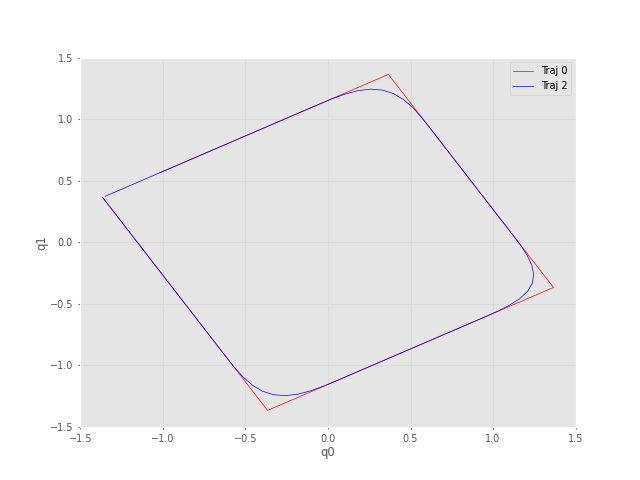

In [22]:
plt.figure()
plt.plot(traj0.q[:, 0], traj0.q[:, 1], color="red", label="Traj 0")
plt.plot(traj2.q[:, 0], traj2.q[:, 1], color="blue", label="Traj 2")
plt.xlabel("q0")
plt.ylabel("q1")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
len(traj0), len(traj2)

(28, 80)

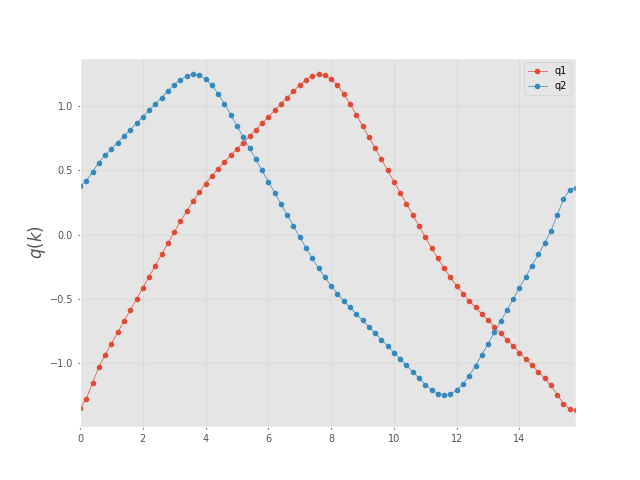

In [24]:
traj2.plot()

### Interpolation of Orientation in 3D

In [25]:
R0 = SO3.Rz(-1) * SO3.Ry(-1)
R1 = SO3.Rz(1) * SO3.Ry(1)

In [26]:
rpy0 = R0.rpy()
rpy1 = R1.rpy()

In [27]:
traj = mtraj(quintic, rpy0, rpy1, 50)

In [28]:
traj.q

array([[       0,       -1,       -1],
       [       0,  -0.9998,  -0.9998],
       [       0,  -0.9987,  -0.9987],
       [       0,  -0.9958,  -0.9958],
       [       0,  -0.9904,  -0.9904],
       [       0,  -0.9819,  -0.9819],
       [       0,  -0.9697,  -0.9697],
       [       0,  -0.9535,  -0.9535],
       [       0,  -0.9329,  -0.9329],
       [       0,  -0.9077,  -0.9077],
       [       0,  -0.8778,  -0.8778],
       [       0,  -0.8431,  -0.8431],
       [       0,  -0.8036,  -0.8036],
       [       0,  -0.7594,  -0.7594],
       [       0,  -0.7106,  -0.7106],
       [       0,  -0.6575,  -0.6575],
       [       0,  -0.6002,  -0.6002],
       [       0,  -0.5391,  -0.5391],
       [       0,  -0.4746,  -0.4746],
       [       0,   -0.407,   -0.407],
       [       0,  -0.3367,  -0.3367],
       [       0,  -0.2642,  -0.2642],
       [       0,    -0.19,    -0.19],
       [       0,  -0.1145,  -0.1145],
       [       0, -0.03825, -0.03825],
       [       0,  0.0382

In [29]:
pose = SO3.RPY(traj.q)
len(pose)

50

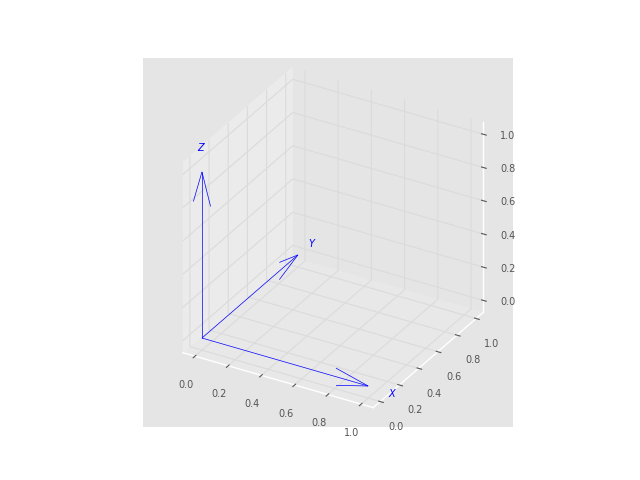

In [30]:
pose.animate()

In [31]:
q0 = UnitQuaternion(R0)
q1 = UnitQuaternion(R1)

In [32]:
qtraj = q0.interp(q1, 50)
len(qtraj)

50

In [33]:
qtraj.animate()

#### Direction of Rotation

In [34]:
q0 = UnitQuaternion.Rz(-2)
q1 = UnitQuaternion.Rz(2)
q = q0.interp(q1, 50)
q.animate()

In [35]:
q = q0.interp(q1, 50, shortest=True)
q.animate()

### Cartesian Motion in 3D

In [36]:
T0 = SE3.Trans([0.4, 0.2, 0]) * SE3.RPY(0, 0, 3)
T1 = SE3.Trans([-0.4, -0.2, 0.3]) * SE3.RPY(-pi/4, pi/4, -pi/2)

In [37]:
T0.interp(T1, 0.5)

  -0.7205    0.6578    0.2196    0         
  -0.6578   -0.5479   -0.5168    0         
  -0.2196   -0.5168    0.8274    0.15      
   0         0         0         1         


In [38]:
Ts = T0.interp(T1, 51)

In [39]:
len(Ts)

51

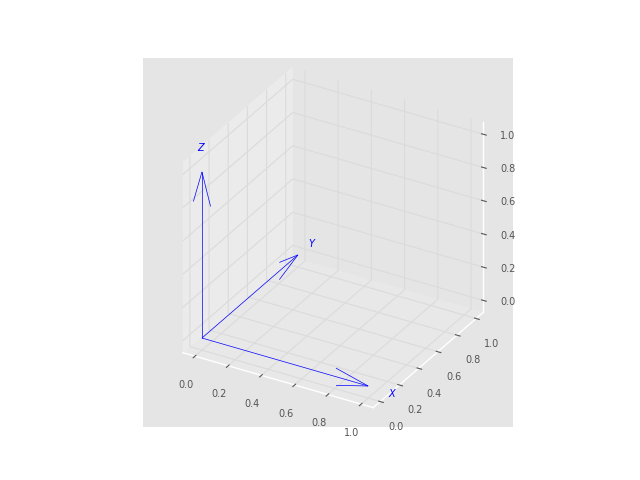

In [40]:
plt.close('all')

Ts.animate()

In [41]:
Ts[25]

  -0.7205    0.6578    0.2196    0         
  -0.6578   -0.5479   -0.5168    0         
  -0.2196   -0.5168    0.8274    0.15      
   0         0         0         1         


In [42]:
P = Ts.t
P.shape

(51, 3)

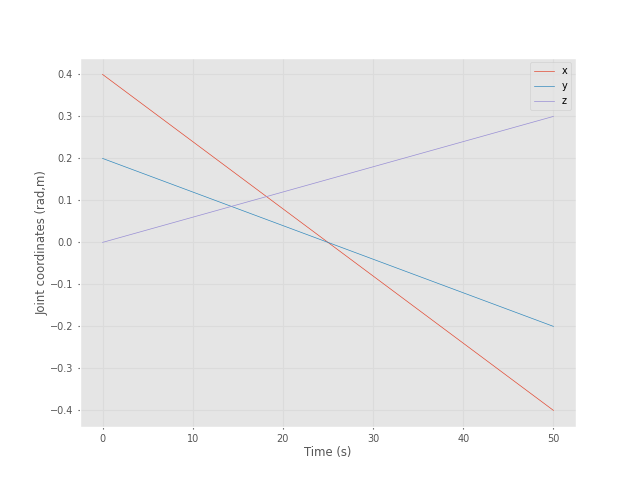

[<Axes: xlabel='Time (s)', ylabel='Joint coordinates (rad,m)'>]

In [43]:
xplot(P, labels="x y z")

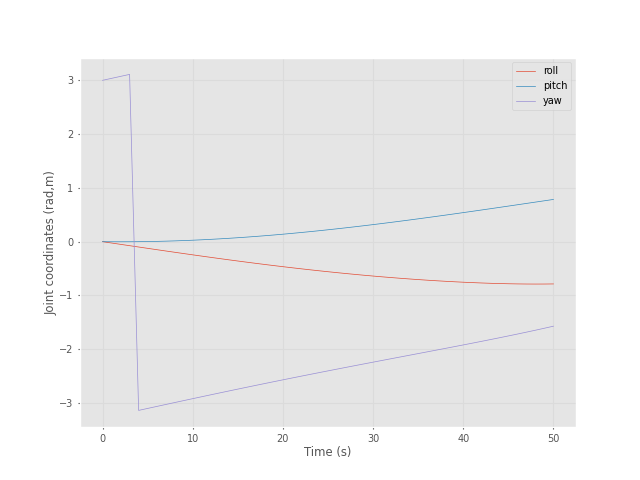

[<Axes: xlabel='Time (s)', ylabel='Joint coordinates (rad,m)'>]

In [44]:
rpy = Ts.rpy()
xplot(rpy, labels="roll pitch yaw")

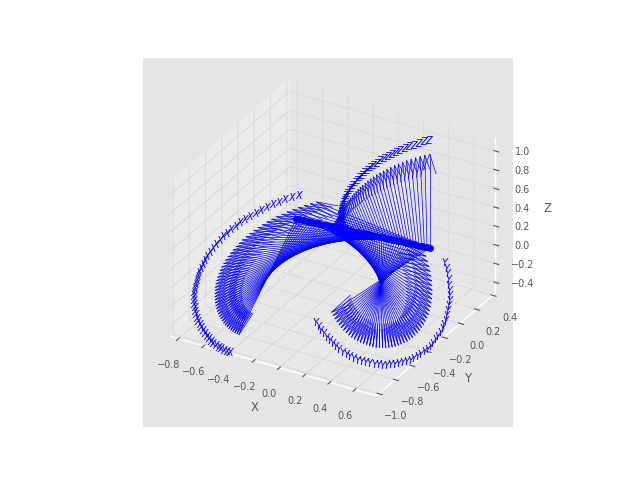

In [45]:
Ts.plot()

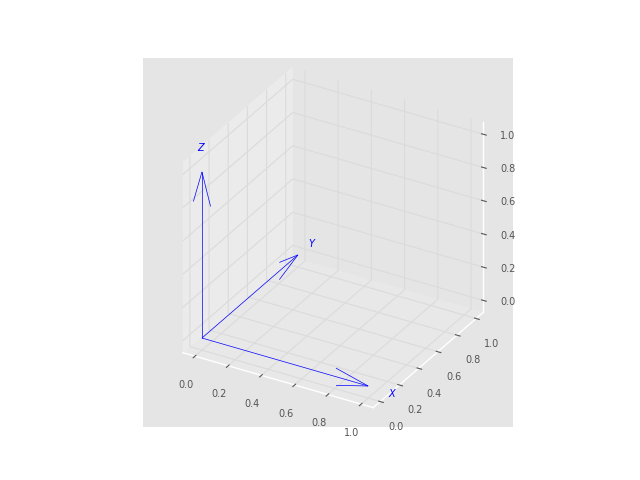

In [46]:
Ts = T0.interp(T1, trapezoidal(0, 1, 50).q)

plt.close('all')

Ts.animate()

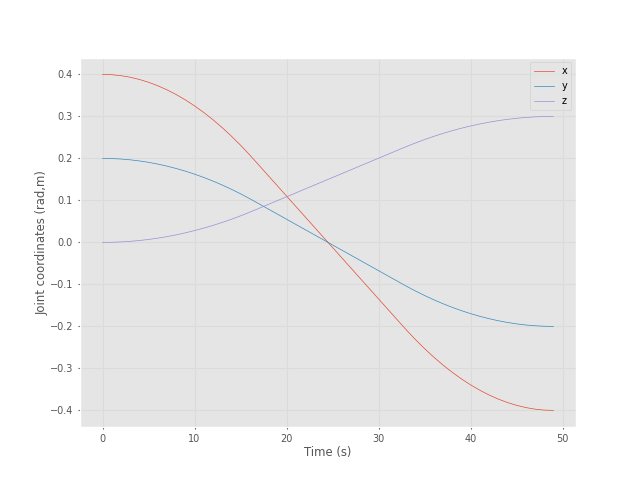

[<Axes: xlabel='Time (s)', ylabel='Joint coordinates (rad,m)'>]

In [47]:
P = Ts.t
xplot(P, labels="x y z")

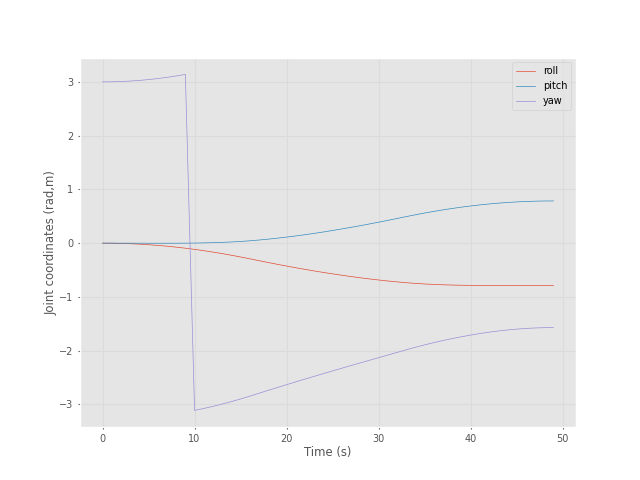

[<Axes: xlabel='Time (s)', ylabel='Joint coordinates (rad,m)'>]

In [48]:
rpy = Ts.rpy()
xplot(rpy, labels="roll pitch yaw")

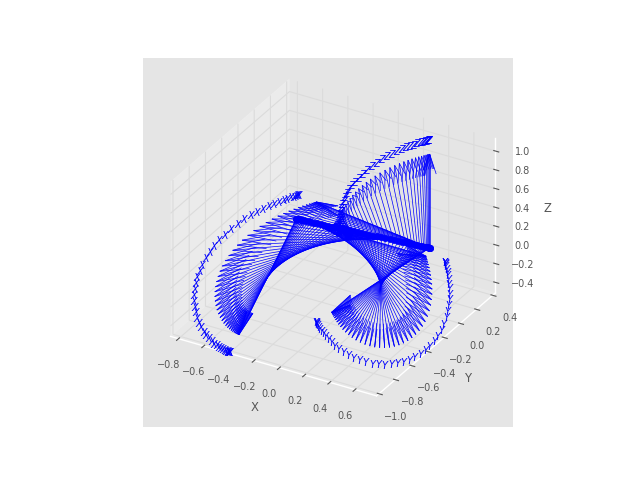

In [49]:
Ts.plot()

In [50]:
Ts = ctraj(T0, T1, 50)